<a href="https://colab.research.google.com/github/heewonLEE2/Paper-Implementations/blob/main/CV/ViT_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔭 ViT (Vision Transformer) — From Scratch

논문: *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale (Dosovitskiy et al., 2020)*

---
## 전체 파이프라인
```
Image → Patch Split → Linear Projection → [CLS] + Positional Encoding
      → Transformer Encoder (x N) → MLP Head → Class Prediction
```
---

## Cell 1 — 라이브러리 Import & GPU 확인

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## Cell 2 — 하이퍼파라미터 설정

Colab 환경에 맞게 경량화한 ViT 설정입니다.

| 파라미터 | 값 | 설명 |
|---|---|---|
| `IMAGE_SIZE` | 32 | CIFAR-10 이미지 크기 |
| `PATCH_SIZE` | 4 | 각 패치의 크기 (4×4) |
| `NUM_PATCHES` | 64 | (32/4)² = 64개 패치 |
| `EMBED_DIM` | 256 | 패치 임베딩 차원 |
| `NUM_HEADS` | 8 | Multi-head attention 헤드 수 |
| `NUM_LAYERS` | 6 | Transformer Encoder 반복 횟수 |
| `MLP_DIM` | 512 | MLP hidden layer 차원 |

In [2]:
# ── 이미지 / 패치 설정 ──────────────────────────────────────────
IMAGE_SIZE   = 32    # CIFAR-10 이미지 크기
PATCH_SIZE   = 4     # 한 패치의 가로/세로 픽셀 수
IN_CHANNELS  = 3     # RGB
NUM_CLASSES  = 10    # CIFAR-10 클래스 수

# ── Transformer 설정 ───────────────────────────────────────────
NUM_PATCHES  = (IMAGE_SIZE // PATCH_SIZE) ** 2   # 64
PATCH_DIM    = IN_CHANNELS * PATCH_SIZE ** 2     # 3*4*4 = 48
EMBED_DIM    = 256   # 패치 임베딩 차원
NUM_HEADS    = 8     # Multi-Head Attention 헤드 수
NUM_LAYERS   = 6     # Transformer Encoder 블록 반복 횟수
MLP_DIM      = 512   # MLP Feed-Forward hidden 차원
DROPOUT      = 0.1

# ── 학습 설정 ──────────────────────────────────────────────────
BATCH_SIZE   = 128
EPOCHS       = 20
LEARNING_RATE = 3e-4

print(f'패치 수       : {NUM_PATCHES}')
print(f'패치 차원     : {PATCH_DIM}')
print(f'임베딩 차원   : {EMBED_DIM}')

패치 수       : 64
패치 차원     : 48
임베딩 차원   : 256


## Cell 3 — Patch Embedding

논문의 핵심 아이디어: **이미지를 패치 시퀀스로 변환**

```
Image (3, 32, 32)
  → 64개의 패치 (64, 48)     # 각 패치: 4×4×3 = 48 픽셀값
  → Linear Projection (64, 256)  # EMBED_DIM으로 매핑
```

구현 포인트: `Conv2d(stride=patch_size)` 로 패치 분할 + 임베딩을 한 번에!

In [3]:
class PatchEmbedding(nn.Module):
    """
    이미지를 패치로 분할하고 EMBED_DIM 차원으로 선형 투영합니다.
    Conv2d(kernel_size=patch_size, stride=patch_size)를 사용해
    패치 분할과 선형 변환을 한 번에 처리합니다.
    """
    def __init__(self, in_channels, patch_size, embed_dim):
        super().__init__()
        self.patch_size = patch_size

        # kernel = patch_size, stride = patch_size → 겹치지 않는 패치 추출
        self.projection = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.projection(x)        # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)              # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)         # (B, num_patches, embed_dim)
        return x

# ── 동작 확인 ─────────────────────────────────────────────────
dummy_img = torch.randn(4, IN_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
patch_embed = PatchEmbedding(IN_CHANNELS, PATCH_SIZE, EMBED_DIM)
out = patch_embed(dummy_img)
print(f'입력 이미지 shape  : {dummy_img.shape}')   # (4, 3, 32, 32)
print(f'패치 임베딩 shape  : {out.shape}')          # (4, 64, 256)

입력 이미지 shape  : torch.Size([4, 3, 32, 32])
패치 임베딩 shape  : torch.Size([4, 64, 256])


## Cell 4 — Multi-Head Self-Attention (MHSA)

각 패치 토큰이 **다른 모든 패치들과의 관계**를 학습합니다.

```
Attention(Q, K, V) = softmax(QKᵀ / √d_k) · V
```

- Q, K, V : 입력 X를 각각 선형변환한 행렬
- `√d_k`  : 내적값이 너무 커지는 것을 방지하는 스케일링
- `nn.MultiheadAttention` 을 사용해 간결하게 구현

In [4]:
class MultiHeadSelfAttention(nn.Module):
    """
    Multi-Head Self-Attention 블록.
    PyTorch의 nn.MultiheadAttention을 래핑해 사용합니다.
    """
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True   # (B, seq, dim) 순서 사용
        )

    def forward(self, x):
        # Self-Attention: Q = K = V = x
        # attn_output: (B, seq_len, embed_dim)
        # attn_weights: (B, seq_len, seq_len)
        attn_output, attn_weights = self.attn(x, x, x)
        return attn_output, attn_weights

# ── 동작 확인 ─────────────────────────────────────────────────
mhsa = MultiHeadSelfAttention(EMBED_DIM, NUM_HEADS)
dummy_tokens = torch.randn(4, NUM_PATCHES, EMBED_DIM)  # (B, seq, dim)
attn_out, attn_w = mhsa(dummy_tokens)
print(f'Attention 출력 shape  : {attn_out.shape}')   # (4, 64, 256)
print(f'Attention 가중치 shape: {attn_w.shape}')     # (4, 64, 64)

Attention 출력 shape  : torch.Size([4, 64, 256])
Attention 가중치 shape: torch.Size([4, 64, 64])


## Cell 5 — MLP Block

Transformer의 FFN(Feed-Forward Network) 부분입니다.

```
x → Linear(embed_dim → mlp_dim) → GELU → Dropout → Linear(mlp_dim → embed_dim) → Dropout
```

논문에서는 활성화 함수로 **GELU** 를 사용합니다.

In [5]:
class MLPBlock(nn.Module):
    """
    Transformer 내부의 Feed-Forward Network (FFN).
    embed_dim → mlp_dim → embed_dim 구조.
    """
    def __init__(self, embed_dim, mlp_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),           # 논문에서 ReLU 대신 GELU 사용
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

# ── 동작 확인 ─────────────────────────────────────────────────
mlp = MLPBlock(EMBED_DIM, MLP_DIM)
mlp_out = mlp(dummy_tokens)
print(f'MLP 출력 shape: {mlp_out.shape}')  # (4, 64, 256)

MLP 출력 shape: torch.Size([4, 64, 256])


## Cell 6 — Transformer Encoder Block

논문의 Encoder 블록 1개 단위입니다.

```
x → LayerNorm → MHSA → (+잔차연결) → LayerNorm → MLP → (+잔차연결)
```

**Pre-LN 구조**: 원래 Transformer는 Post-LN이지만 ViT는 Pre-LN을 사용해 학습 안정성을 높입니다.

In [6]:
class TransformerEncoderBlock(nn.Module):
    """
    ViT의 단일 Transformer Encoder 블록.
    Pre-LN 구조: LayerNorm → Attention/MLP → Residual Connection
    """
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.0):
        super().__init__()

        # Attention 경로
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, dropout)

        # MLP 경로
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp   = MLPBlock(embed_dim, mlp_dim, dropout)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # 1) Attention + Residual
        attn_out, attn_weights = self.attn(self.norm1(x))
        x = x + self.dropout(attn_out)

        # 2) MLP + Residual
        x = x + self.dropout(self.mlp(self.norm2(x)))

        return x, attn_weights

# ── 동작 확인 ─────────────────────────────────────────────────
enc_block = TransformerEncoderBlock(EMBED_DIM, NUM_HEADS, MLP_DIM, DROPOUT)
enc_out, enc_attn = enc_block(dummy_tokens)
print(f'Encoder 출력 shape: {enc_out.shape}')   # (4, 64, 256)

Encoder 출력 shape: torch.Size([4, 64, 256])


## Cell 7 — ViT 전체 모델

모든 컴포넌트를 조합한 완성 모델입니다.

```
Image
 │
 ├─ Patch Embedding   → (B, 64, 256)
 ├─ [CLS] 토큰 추가  → (B, 65, 256)  ← 분류에 사용할 특수 토큰
 ├─ Positional Encoding 더하기       ← 패치 위치 정보 부여
 ├─ Dropout
 │
 ├─ Transformer Encoder × 6
 │
 ├─ LayerNorm
 ├─ CLS 토큰만 추출  → (B, 256)
 └─ MLP Head          → (B, 10)       ← 최종 분류
```

In [7]:
class ViT(nn.Module):
    """
    Vision Transformer (ViT) — Full Model
    """
    def __init__(
        self,
        image_size   = IMAGE_SIZE,
        patch_size   = PATCH_SIZE,
        in_channels  = IN_CHANNELS,
        num_classes  = NUM_CLASSES,
        embed_dim    = EMBED_DIM,
        num_heads    = NUM_HEADS,
        num_layers   = NUM_LAYERS,
        mlp_dim      = MLP_DIM,
        dropout      = DROPOUT
    ):
        super().__init__()
        num_patches = (image_size // patch_size) ** 2

        # 1. Patch Embedding
        self.patch_embed = PatchEmbedding(in_channels, patch_size, embed_dim)

        # 2. [CLS] 토큰: 학습 가능한 파라미터
        #    분류 시 이 토큰의 출력만 사용
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # 3. Positional Encoding: 각 토큰 위치 정보 (CLS + 패치 수)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))

        self.pos_dropout = nn.Dropout(dropout)

        # 4. Transformer Encoder 블록 N개
        self.transformer = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])

        # 5. 최종 LayerNorm
        self.norm = nn.LayerNorm(embed_dim)

        # 6. 분류 헤드: CLS 토큰 → 클래스 수
        self.mlp_head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]

        # Patch Embedding: (B, num_patches, embed_dim)
        x = self.patch_embed(x)

        # CLS 토큰을 배치 크기만큼 복사해서 앞에 붙이기
        cls_tokens = self.cls_token.expand(B, -1, -1)   # (B, 1, embed_dim)
        x = torch.cat([cls_tokens, x], dim=1)           # (B, num_patches+1, embed_dim)

        # Positional Encoding 더하기
        x = x + self.pos_embed
        x = self.pos_dropout(x)

        # Transformer Encoder 통과
        attn_weights_list = []
        for block in self.transformer:
            x, attn_w = block(x)
            attn_weights_list.append(attn_w)

        x = self.norm(x)

        # CLS 토큰만 추출해서 분류
        cls_output = x[:, 0]          # (B, embed_dim)
        logits = self.mlp_head(cls_output)   # (B, num_classes)

        return logits, attn_weights_list

# ── 모델 생성 및 파라미터 수 확인 ────────────────────────────────
model = ViT().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'총 학습 파라미터 수: {total_params:,}')

# 전체 forward 동작 확인
dummy = torch.randn(4, IN_CHANNELS, IMAGE_SIZE, IMAGE_SIZE).to(device)
logits, attn_maps = model(dummy)
print(f'출력 logits shape: {logits.shape}')  # (4, 10)

총 학습 파라미터 수: 3,195,146
출력 logits shape: torch.Size([4, 10])


## Cell 8 — 데이터셋 준비 (CIFAR-10)

Train 샘플 수: 50000
Test  샘플 수: 10000


/tmp/ipykernel_628/3809950113.py:44: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_628/3809950113.py:44: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_628/3809950113.py:44: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_628/3809950113.py:44: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_628/3809950113.py:44: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


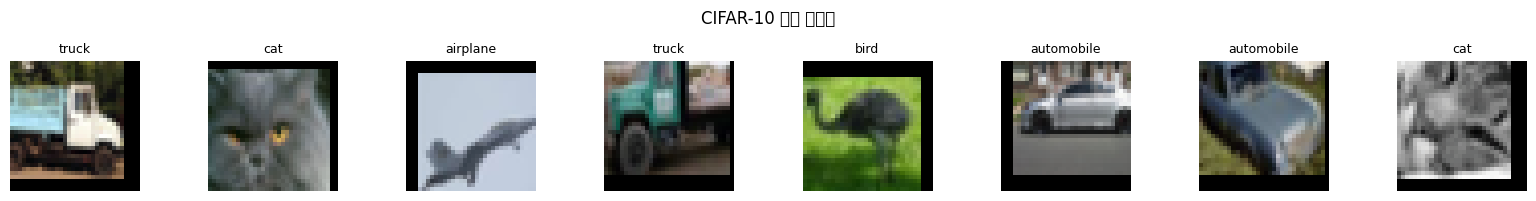

In [9]:
# ── 데이터 전처리 정의 ────────────────────────────────────────
# CIFAR-10 정규화 값 (ImageNet 기준 아닌 CIFAR-10 기준)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),    # 데이터 증강: 좌우 반전
    transforms.RandomCrop(32, padding=4), # 데이터 증강: 랜덤 크롭
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# ── 데이터셋 다운로드 및 DataLoader 생성 ─────────────────────
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASSES = ('airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck')
print(f'Train 샘플 수: {len(train_dataset)}')
print(f'Test  샘플 수: {len(test_dataset)}')

# ── 샘플 이미지 시각화 ────────────────────────────────────────
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img = images[i].permute(1, 2, 0).numpy()
    img = img * np.array(CIFAR_STD) + np.array(CIFAR_MEAN)  # 역정규화
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('CIFAR-10 샘플 이미지', fontsize=12)
plt.tight_layout()
plt.show()

## Cell 9 — 학습 설정 (Loss / Optimizer / Scheduler)

- **Optimizer**: AdamW (ViT 논문 권장, weight decay 적용)
- **Scheduler**: CosineAnnealingLR (학습률을 코사인 곡선으로 감소)
- **Loss**: CrossEntropyLoss

In [10]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing으로 과적합 방지

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

# 학습률을 코사인 곡선으로 감소시키는 스케줄러
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

print('Optimizer:', optimizer.__class__.__name__)
print('Scheduler:', scheduler.__class__.__name__)

Optimizer: AdamW
Scheduler: CosineAnnealingLR


## Cell 10 — 학습 루프

In [11]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits, _ = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits, _ = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


# ── 전체 학습 실행 ────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = evaluate(model, test_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    # 최고 성능 모델 저장
    if va_acc > best_acc:
        best_acc = va_acc
        torch.save(model.state_dict(), 'best_vit.pth')

    print(f'Epoch [{epoch:2d}/{EPOCHS}]  '
          f'Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc*100:.2f}%  '
          f'Val Loss: {va_loss:.4f}  Val Acc: {va_acc*100:.2f}%')

print(f'\n✅ Best Validation Accuracy: {best_acc*100:.2f}%')

Epoch [ 1/20]  Train Loss: 1.8792  Train Acc: 35.17%  Val Loss: 1.6441  Val Acc: 47.73%
Epoch [ 2/20]  Train Loss: 1.6530  Train Acc: 46.69%  Val Loss: 1.5382  Val Acc: 52.89%
Epoch [ 3/20]  Train Loss: 1.5524  Train Acc: 51.28%  Val Loss: 1.4734  Val Acc: 55.48%
Epoch [ 4/20]  Train Loss: 1.4917  Train Acc: 54.29%  Val Loss: 1.4139  Val Acc: 58.22%
Epoch [ 5/20]  Train Loss: 1.4410  Train Acc: 56.79%  Val Loss: 1.3484  Val Acc: 61.30%
Epoch [ 6/20]  Train Loss: 1.3999  Train Acc: 58.89%  Val Loss: 1.3121  Val Acc: 63.34%
Epoch [ 7/20]  Train Loss: 1.3629  Train Acc: 60.44%  Val Loss: 1.3078  Val Acc: 63.28%
Epoch [ 8/20]  Train Loss: 1.3292  Train Acc: 62.03%  Val Loss: 1.2763  Val Acc: 65.16%
Epoch [ 9/20]  Train Loss: 1.3020  Train Acc: 63.66%  Val Loss: 1.2574  Val Acc: 65.81%
Epoch [10/20]  Train Loss: 1.2700  Train Acc: 64.94%  Val Loss: 1.2277  Val Acc: 66.91%
Epoch [11/20]  Train Loss: 1.2506  Train Acc: 65.80%  Val Loss: 1.2092  Val Acc: 67.72%
Epoch [12/20]  Train Loss: 1.222

## Cell 11 — 학습 결과 시각화

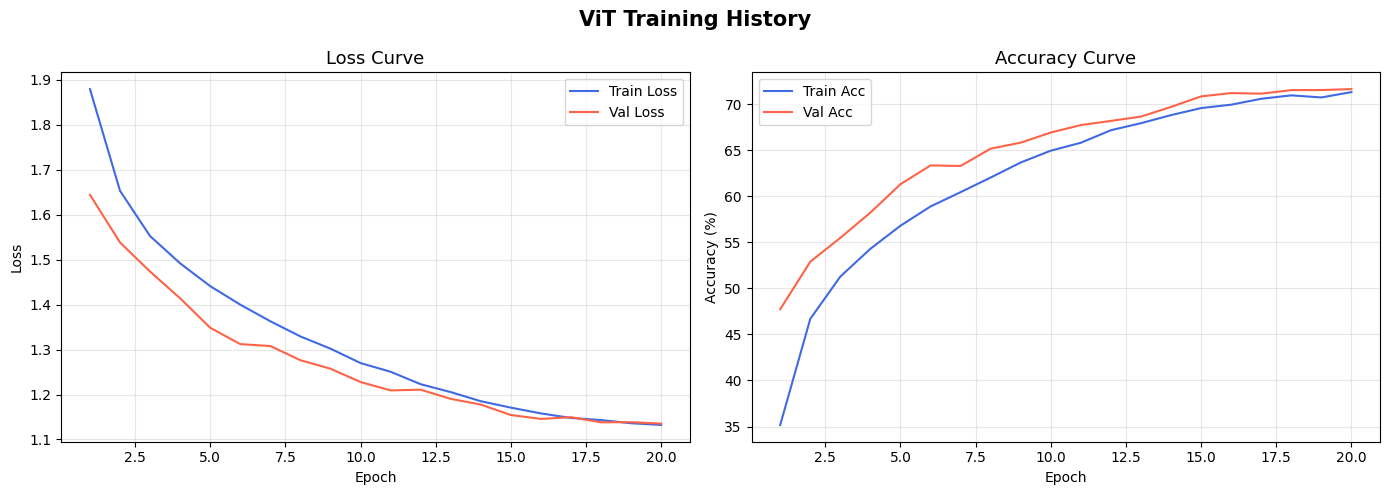

Final Val Accuracy: 71.62%


In [12]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss 그래프
ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='royalblue')
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato')
ax1.set_title('Loss Curve', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy 그래프
ax2.plot(epochs_range, [a*100 for a in history['train_acc']], label='Train Acc', color='royalblue')
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val Acc',   color='tomato')
ax2.set_title('Accuracy Curve', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('ViT Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Final Val Accuracy: {history["val_acc"][-1]*100:.2f}%')

## Cell 12 — Attention Map 시각화

ViT의 강점인 **Attention Map**을 시각화합니다.
마지막 Transformer 블록의 CLS 토큰이 각 패치에 얼마나 주목하는지 확인할 수 있습니다.

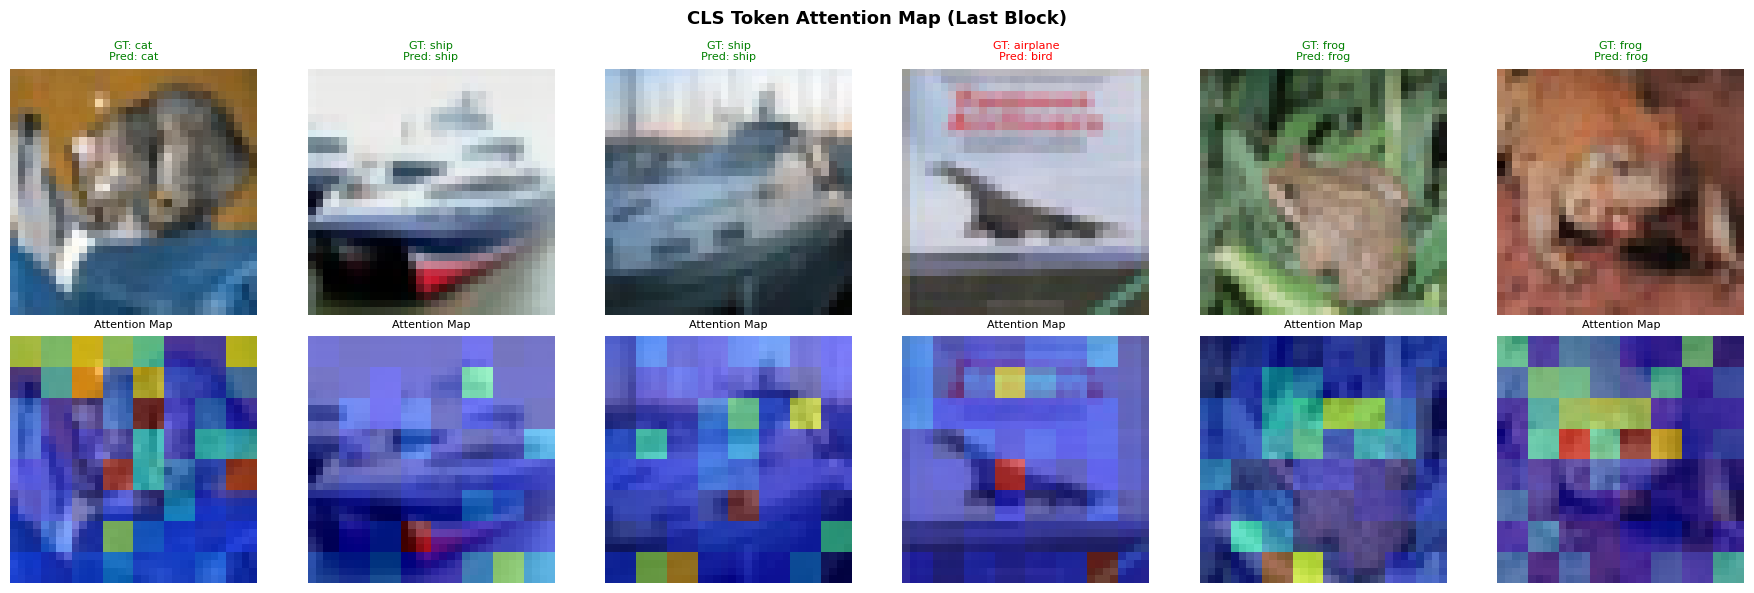

In [13]:
# 저장된 best 모델 불러오기
model.load_state_dict(torch.load('best_vit.pth', map_location=device))
model.eval()

# 테스트 샘플 가져오기
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    logits, attn_weights_list = model(images)

# 마지막 블록의 Attention 가중치 사용
# attn_weights: (B, num_patches+1, num_patches+1)
last_attn = attn_weights_list[-1].cpu()  # (B, 65, 65)

# CLS 토큰(index=0)이 각 패치에 주목하는 정도만 추출
cls_attn = last_attn[:, 0, 1:]  # (B, num_patches=64)

# num_patches → (H/P, W/P) 로 reshape
grid_size = IMAGE_SIZE // PATCH_SIZE   # 8
cls_attn  = cls_attn.reshape(-1, grid_size, grid_size)  # (B, 8, 8)

# ── 시각화 ───────────────────────────────────────────────────
n_show = 6
fig, axes = plt.subplots(2, n_show, figsize=(18, 6))

for i in range(n_show):
    pred = logits[i].argmax().item()
    gt   = labels[i].item()

    # 원본 이미지
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = img * np.array(CIFAR_STD) + np.array(CIFAR_MEAN)
    img = np.clip(img, 0, 1)
    axes[0, i].imshow(img)
    color = 'green' if pred == gt else 'red'
    axes[0, i].set_title(f'GT: {CLASSES[gt]}\nPred: {CLASSES[pred]}', fontsize=8, color=color)
    axes[0, i].axis('off')

    # Attention Map (업샘플링해서 원본 크기에 overlay)
    attn_map = cls_attn[i].numpy()
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
    axes[1, i].imshow(img)
    axes[1, i].imshow(
        np.kron(attn_map, np.ones((PATCH_SIZE, PATCH_SIZE))),  # 패치 크기로 확대
        alpha=0.5, cmap='jet'
    )
    axes[1, i].set_title('Attention Map', fontsize=8)
    axes[1, i].axis('off')

plt.suptitle('CLS Token Attention Map (Last Block)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()